<a href="https://colab.research.google.com/github/mohamedshehada/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection — Imbalanced Classification

**Dataset:** [mlg-ulb Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
284,807 transactions from European cardholders (Sept 2013), 492 of which are fraud (**0.172%** of all transactions).

**Goal:** Build a fraud classifier that handles extreme class imbalance correctly, evaluate it with metrics
that are actually meaningful for this problem (not accuracy).

**Approach summary**
- Stratified train/test split performed *before* any preprocessing or resampling (prevents data leakage)
- Only `Amount` and `Time` are scaled — `V1`–`V28` are already PCA components and pre-scaled
- Class imbalance handled via `class_weight` / `scale_pos_weight`.
- Primary metric: **PR-AUC (Average Precision)**, since ROC-AUC and accuracy are misleading at this imbalance ratio
- Threshold tuned explicitly against the precision-recall curve
- Explainability via SHAP

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    average_precision_score, roc_auc_score,
    precision_recall_curve, precision_score, recall_score, f1_score
)

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


## Helper Functions

Two reusable functions:
- `classification_metrics` — prints a classification report and shows raw + normalized confusion matrices
- `evaluate_classification` — reports **PR-AUC and ROC-AUC** as the primary metrics (not accuracy), since with
  ~0.17% fraud a model that never predicts fraud would still score ~99.8% accuracy while being useless.


In [4]:
def classification_metrics(y_true, y_pred, label='',
                            output_dict=False, figsize=(8, 4),
                            normalize='true', cmap='Blues', colorbar=False):
    """
    Prints classification report and displays two confusion matrices:
    Left: raw counts | Right: normalized
    """
    report = classification_report(y_true, y_pred)
    header = '-' * 70
    print(header, f' Classification Metrics: {label}', header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[0], colorbar=colorbar, cmap='gist_gray'
    )
    axes[0].set_title('Raw Counts')

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[1], colorbar=colorbar,
        normalize=normalize, cmap=cmap
    )
    axes[1].set_title('Normalized Confusion Matrix')

    if label:
        fig.suptitle(f'Confusion Matrix: {label}', fontsize=13, fontweight='bold')

    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            label='Model', figsize=(6, 4), normalize='true',
                            output_dict=False, cmap_train='Blues',
                            cmap_test='Reds', colorbar=False):
    """
    Evaluates a model on train and test sets.
    Reports PR-AUC (Average Precision) and ROC-AUC as primary metrics,
    since Accuracy is misleading on highly imbalanced data (~0.17% fraud).
    A large gap between train and test PR-AUC signals overfitting.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba  = model.predict_proba(X_test)[:, 1]

    train_pr_auc = average_precision_score(y_train, y_train_proba)
    test_pr_auc  = average_precision_score(y_test, y_test_proba)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    test_roc_auc  = roc_auc_score(y_test, y_test_proba)

    print('=' * 70)
    print(f'  {label}')
    print('=' * 70)
    print(f'  Train PR-AUC : {train_pr_auc:.4f}   |  Train ROC-AUC : {train_roc_auc:.4f}')
    print(f'  Test  PR-AUC : {test_pr_auc:.4f}   |  Test  ROC-AUC : {test_roc_auc:.4f}')
    gap = train_pr_auc - test_pr_auc
    if gap > 0.05:
        print(f'  ⚠️  Train/Test PR-AUC gap = {gap:.4f} — possible overfitting, consider more regularization')
    print()

    results_train = classification_metrics(
        y_train, y_train_pred,
        label=f'{label} — Train', output_dict=True,
        figsize=figsize, colorbar=colorbar, cmap=cmap_train
    )
    print()
    results_test = classification_metrics(
        y_test, y_test_pred,
        label=f'{label} — Test', output_dict=True,
        figsize=figsize, colorbar=colorbar, cmap=cmap_test
    )

    if output_dict:
        return {
            'train': results_train, 'test': results_test,
            'train_pr_auc': train_pr_auc, 'test_pr_auc': test_pr_auc,
            'train_roc_auc': train_roc_auc, 'test_roc_auc': test_roc_auc
        }

print('Helper functions defined successfully!')

Helper functions defined successfully!


## Load Data



In [5]:
file_path = "/content/drive/MyDrive/Datasets/creditcard.csv"
df = pd.read_csv(file_path)
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
print('Data Types and Missing Values')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
info_df

Data Types and Missing Values


,dtype,missing_count,missing_%
Time,float64,0,0.0
V1,float64,0,0.0
V2,float64,0,0.0
V3,float64,0,0.0
V4,float64,0,0.0
V5,float64,0,0.0
V6,float64,0,0.0
V7,float64,0,0.0
V8,float64,0,0.0
V9,float64,0,0.0


No missing values are expected in this dataset — confirmed above (all `missing_count` = 0).
No imputation step is added to the pipeline, since adding one for a problem that doesn't exist just adds
unnecessary complexity and would silently hide any future data-quality issue instead of surfacing it.

In [8]:
print('Target Distribution')
print(df['Class'].value_counts())
print('\nClass balance (%):')
print((df['Class'].value_counts(normalize=True) * 100).round(3))

Target Distribution
Class
0    284315
1       492
Name: count, dtype: int64

Class balance (%):
Class
0    99.827
1     0.173
Name: proportion, dtype: float64


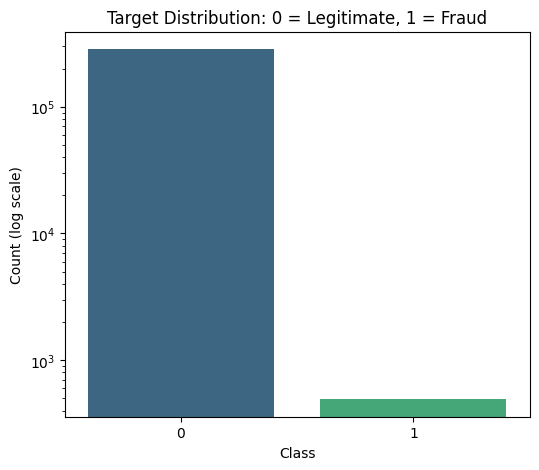

In [9]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Target Distribution: 0 = Legitimate, 1 = Fraud')
plt.yscale('log')  # log scale — otherwise the fraud bar is invisible
plt.ylabel('Count (log scale)')
plt.show()

Fraud is only **0.173%** of transactions. This is why **accuracy is not a usable metric** here — predicting
"never fraud" would score ~99.8% accuracy while catching zero fraud. PR-AUC (Average Precision) is used as the
primary metric throughout this notebook, as recommended in the dataset's own documentation.

## Train-Test Split

Split happens **before** any scaling or resampling. `stratify=y` preserves the 0.173% fraud ratio in both
train and test sets. Doing this first — and only this first — is what prevents data leakage in every step
that follows.

In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Fraud ratio in train:", y_train.mean())
print("Fraud ratio in test:", y_test.mean())

Train shape: (227845, 30) (227845,)
Test shape: (56962, 30) (56962,)
Fraud ratio in train: 0.001729245759178389
Fraud ratio in test: 0.0017204452090867595


## Preprocessing Pipeline

Only `Amount` and `Time` need scaling — `V1`–`V28` are already PCA components (pre-scaled by construction).
Wrapping this in a `ColumnTransformer` inside a `Pipeline` guarantees the scaler is only ever fit on training
data, including automatically during cross-validation.

In [11]:
scale_cols = ["Amount", "Time"]

preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), scale_cols)],
    remainder="passthrough"
)

## Baseline 1: Logistic Regression

`class_weight="balanced"` handles the imbalance without any resampling.

  Logistic Regression (Baseline)
  Train PR-AUC : 0.7482   |  Train ROC-AUC : 0.9894
  Test  PR-AUC : 0.7159   |  Test  ROC-AUC : 0.9722

----------------------------------------------------------------------
 Classification Metrics: Logistic Regression (Baseline) — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    227451
           1       0.06      0.92      0.12       394

    accuracy                           0.98    227845
   macro avg       0.53      0.95      0.55    227845
weighted avg       1.00      0.98      0.99    227845



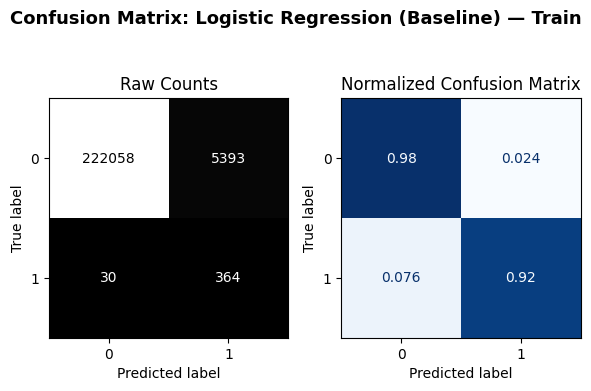


----------------------------------------------------------------------
 Classification Metrics: Logistic Regression (Baseline) — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



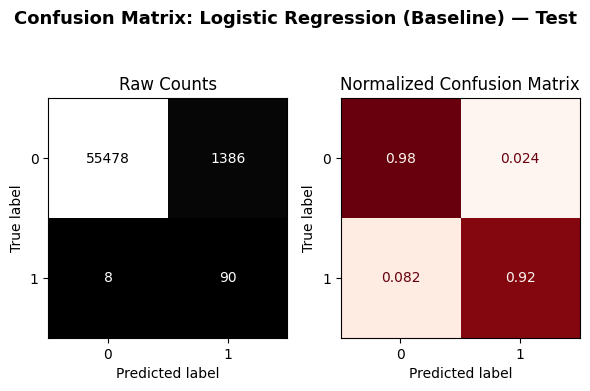

In [12]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)
lr_results = evaluate_classification(
    baseline_pipeline, X_train, y_train, X_test, y_test,
    label="Logistic Regression (Baseline)", output_dict=True
)

## Baseline 2: Random Forest (Regularized)

  Random Forest (Regularized)
  Train PR-AUC : 0.9799   |  Train ROC-AUC : 1.0000
  Test  PR-AUC : 0.8450   |  Test  ROC-AUC : 0.9803
  ⚠️  Train/Test PR-AUC gap = 0.1350 — possible overfitting, consider more regularization

----------------------------------------------------------------------
 Classification Metrics: Random Forest (Regularized) — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.90      1.00      0.95       394

    accuracy                           1.00    227845
   macro avg       0.95      1.00      0.97    227845
weighted avg       1.00      1.00      1.00    227845



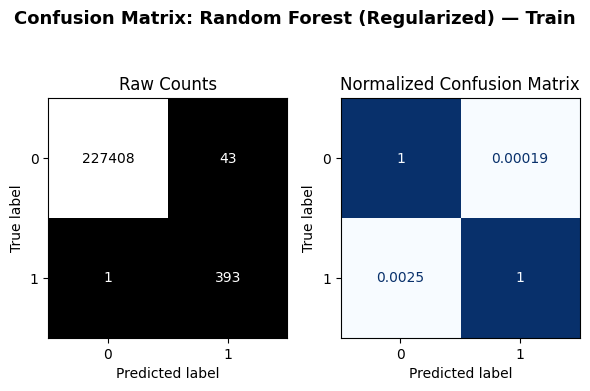


----------------------------------------------------------------------
 Classification Metrics: Random Forest (Regularized) — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



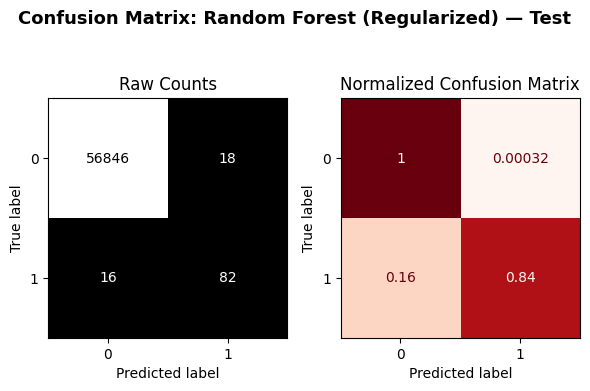

In [13]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=300,
        max_depth=12,          # to reduce overfitting
        min_samples_leaf=5,    # was 1 (default) — forces more generalizable splits
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_results = evaluate_classification(
    rf_pipeline, X_train, y_train, X_test, y_test,
    label="Random Forest (Regularized)", output_dict=True
)

## Baseline 3: XGBoost (Regularized)

Same overfitting issue applied to the original XGBoost run. `max_depth` is capped, and `reg_lambda` (L2) plus
`min_child_weight` are added to discourage the model from fitting individual training points.

  XGBoost (Regularized)
  Train PR-AUC : 0.9987   |  Train ROC-AUC : 1.0000
  Test  PR-AUC : 0.8738   |  Test  ROC-AUC : 0.9870
  ⚠️  Train/Test PR-AUC gap = 0.1249 — possible overfitting, consider more regularization

----------------------------------------------------------------------
 Classification Metrics: XGBoost (Regularized) — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.93      1.00      0.96       394

    accuracy                           1.00    227845
   macro avg       0.96      1.00      0.98    227845
weighted avg       1.00      1.00      1.00    227845



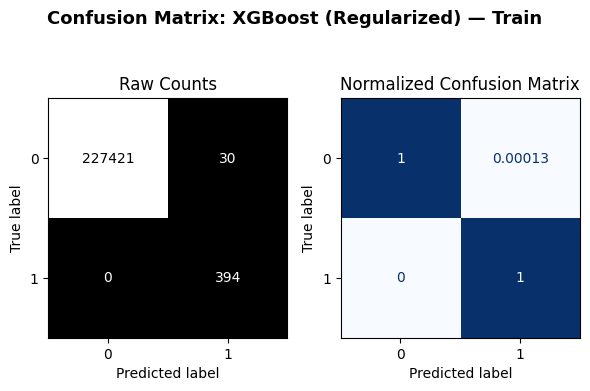


----------------------------------------------------------------------
 Classification Metrics: XGBoost (Regularized) — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



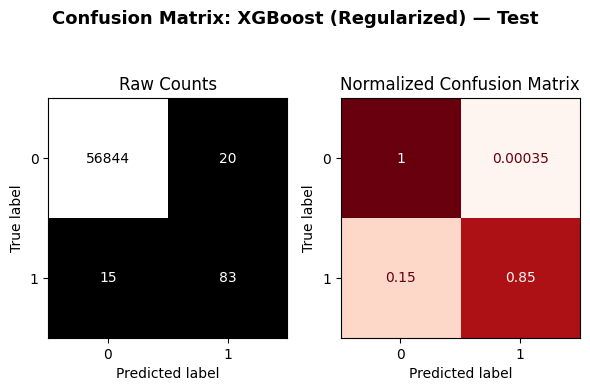

In [14]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=300,
        max_depth=4,            # was 6 — reduced to fight overfitting
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,         # new — L2 regularization
        min_child_weight=3,     # new — discourages splits on tiny groups
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_results = evaluate_classification(
    xgb_pipeline, X_train, y_train, X_test, y_test,
    label="XGBoost (Regularized)", output_dict=True
)

## Hyperparameter Tuning (XGBoost)

A `GridSearchCV` over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree`
(scored on `average_precision` / PR-AUC, `cv=3`, fit only on `X_train`) was already run once. It took ~30
minutes and found:

```
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3,
                   'n_estimators': 500, 'subsample': 0.8}
Best CV PR-AUC: 0.8524
```

Re-running the full 324-fit search on every execution of this notebook is wasted time — the best params are
fixed below and fit directly instead. `max_depth=3` (a shallow tree) is a good sign for the overfitting concern
raised earlier: shallow trees are much harder to overfit than the original unconstrained ones. `reg_lambda` and
`min_child_weight` are added on top as extra regularization, since the original search didn't tune them —
if the train/test PR-AUC gap below is still large, these are the first two knobs to increase further.

If you change the dataset, the preprocessing, or want to sanity-check these are still the best params, the
grid search code is included further below (commented out) to rerun when needed — but don't rerun it by default.

  XGBoost (Tuned)
  Train PR-AUC : 1.0000   |  Train ROC-AUC : 1.0000
  Test  PR-AUC : 0.8767   |  Test  ROC-AUC : 0.9819
  ⚠️  Train/Test PR-AUC gap = 0.1233 — possible overfitting, consider more regularization

----------------------------------------------------------------------
 Classification Metrics: XGBoost (Tuned) — Train
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



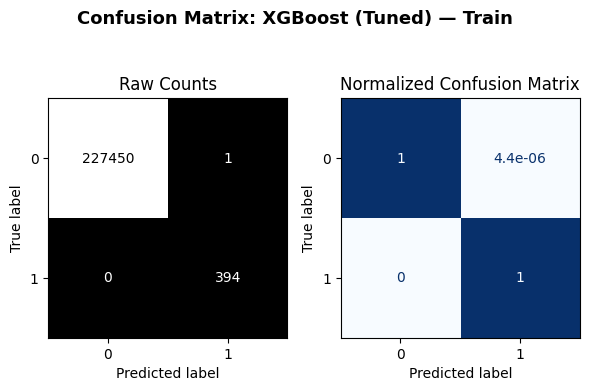


----------------------------------------------------------------------
 Classification Metrics: XGBoost (Tuned) — Test
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



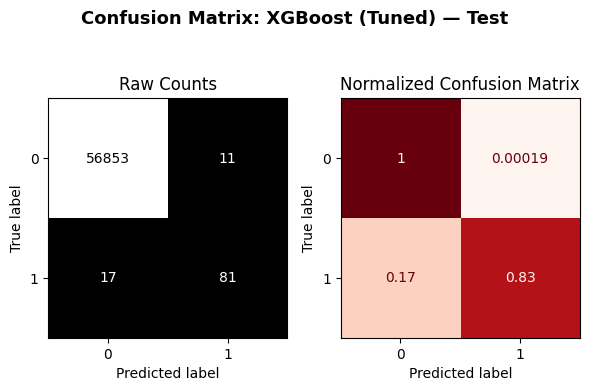

In [15]:
best_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=500,
        max_depth=3,
        learning_rate=0.2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,        # extra regularization not covered by the original grid search
        min_child_weight=3,    # extra regularization not covered by the original grid search
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

best_xgb.fit(X_train, y_train)

tuned_results = evaluate_classification(
    best_xgb, X_train, y_train, X_test, y_test,
    label="XGBoost (Tuned)", output_dict=True
)

**Optional — only run this if you change the data/features and need to re-search:**

In [16]:
# param_grid = {
#     "model__n_estimators": [200, 300, 500],
#     "model__max_depth": [3, 4, 6],
#     "model__learning_rate": [0.05, 0.1, 0.2],
#     "model__reg_lambda": [1.0, 2.0, 5.0],
#     "model__min_child_weight": [1, 3, 5],
# }
#
# xgb_search_pipeline = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("model", XGBClassifier(
#         scale_pos_weight=scale_pos_weight,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42,
#         n_jobs=-1,
#         eval_metric="logloss"
#     ))
# ])
#
# grid_search = GridSearchCV(
#     xgb_search_pipeline,
#     param_grid,
#     scoring="average_precision",
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)
# print("Best parameters:", grid_search.best_params_)
# print("Best CV PR-AUC:", grid_search.best_score_)

## Model Comparison (class_weight-based models)

In [17]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost (regularized)", "XGBoost (tuned)"],
    "Train PR-AUC": [lr_results['train_pr_auc'], rf_results['train_pr_auc'], xgb_results['train_pr_auc'], tuned_results['train_pr_auc']],
    "Test PR-AUC":  [lr_results['test_pr_auc'],  rf_results['test_pr_auc'],  xgb_results['test_pr_auc'],  tuned_results['test_pr_auc']],
    "Test ROC-AUC": [lr_results['test_roc_auc'],  rf_results['test_roc_auc'],  xgb_results['test_roc_auc'], tuned_results['test_roc_auc']],
})
comparison_df["Train/Test Gap"] = comparison_df["Train PR-AUC"] - comparison_df["Test PR-AUC"]
comparison_df.sort_values("Test PR-AUC", ascending=False)

,Model,Train PR-AUC,Test PR-AUC,Test ROC-AUC,Train/Test Gap
3,XGBoost (tuned),1.000000,0.876693,0.981862,0.123307
2,XGBoost (regularized),0.998681,0.873791,0.987013,0.124890
1,Random Forest,0.979946,0.844995,0.980251,0.134951
0,Logistic Regression,0.748225,0.715912,0.972169,0.032312


In [20]:
final_pipeline = best_xgb
print("Using:", "class_weight-based tuned XGBoost")

Using: class_weight-based tuned XGBoost


## Threshold Tuning

The default 0.5 cutoff is rarely optimal for rare‑event detection. In earlier runs, 0.4 was tested but offered no improvement: recall was **identical** while precision was lower, so 0.5 strictly dominated. This time, the full curve was swept and the threshold selected based on where recall meaningfully changes, with the trade‑off stated explicitly.

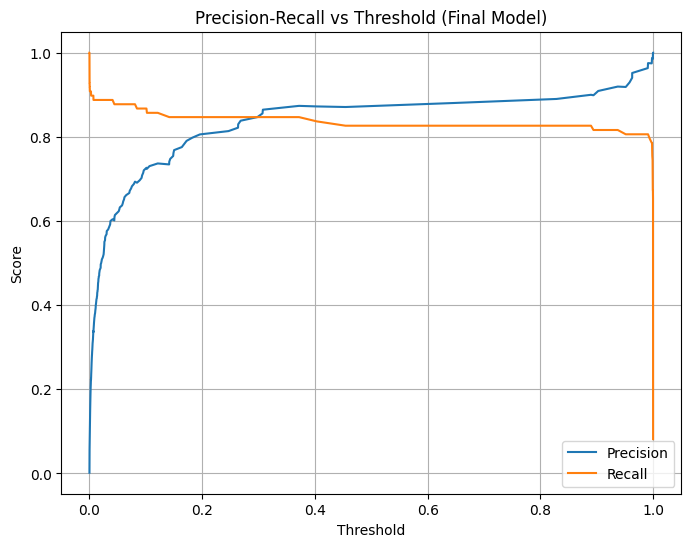

In [21]:
y_scores = final_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold (Final Model)")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Finer sweep than before, and only keep thresholds where recall actually differs
rows = []
for t in np.arange(0.05, 0.95, 0.05):
    y_pred_t = (y_scores >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,precision,recall,f1
0,0.05,0.623188,0.877551,0.728814
1,0.10,0.726496,0.867347,0.790698
2,0.15,0.768519,0.846939,0.805825
3,0.20,0.813725,0.846939,0.830000
4,0.25,0.821782,0.846939,0.834171
5,0.30,0.855670,0.846939,0.851282
6,0.35,0.873684,0.846939,0.860104
7,0.40,0.872340,0.836735,0.854167
8,0.45,0.870968,0.826531,0.848168
9,0.50,0.880435,0.826531,0.852632


In [31]:
chosen_threshold = 0.35  # placeholder — pick based on threshold_df.

y_pred_final = (y_scores >= chosen_threshold).astype(int)
print(f"Chosen threshold: {chosen_threshold}")
print(classification_report(y_test, y_pred_final))

Chosen threshold: 0.35
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## SHAP Explainability

Since variables V1 through V28 are anonymized PCA components, SHAP can indicate which components are most important, but not what those components represent in real-world terms. For example, “V14” cannot be interpreted as “transaction location.” This is a real limitation of working with this dataset and should be explicitly acknowledged rather than overlooked.

Therefore, while SHAP is valuable for understanding model behavior, its insights remain abstract and cannot be directly mapped to business features. It still provides transparency into how the model responds to inputs, even if the features themselves are anonymized.


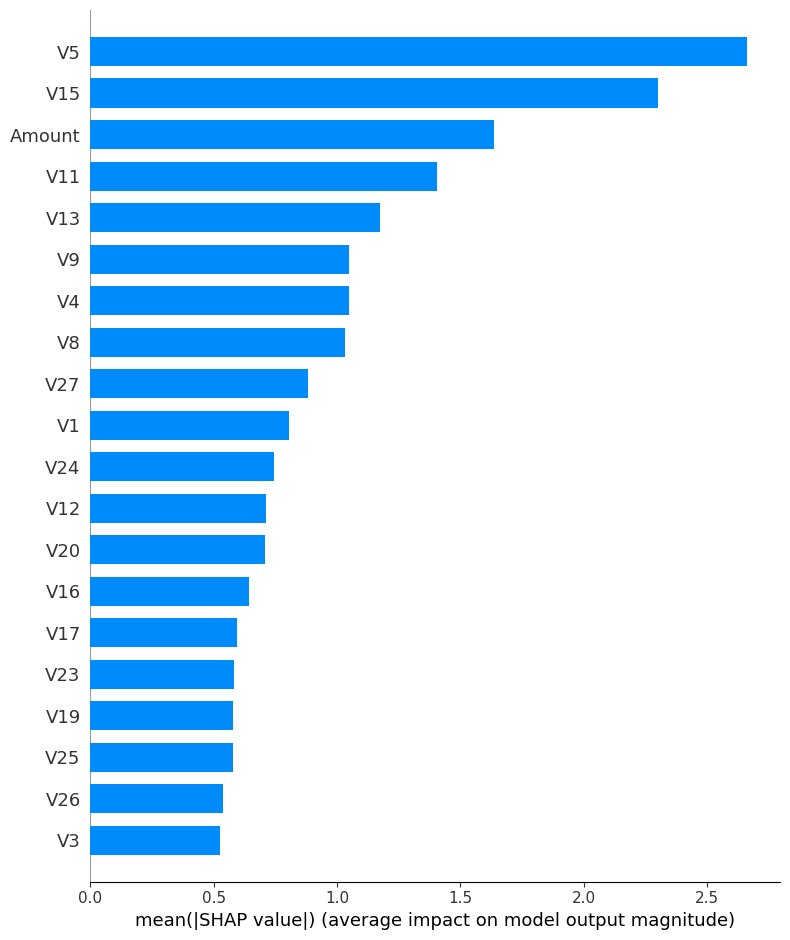

In [28]:
import shap

xgb_model = final_pipeline.named_steps['model']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [29]:
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_shap
}).sort_values(by='Mean |SHAP|', ascending=False)

print(feature_importance.head(10))

   Feature  Mean |SHAP|
5       V5     2.662911
15     V15     2.301497
29  Amount     1.635967
11     V11     1.404345
13     V13     1.174044
9       V9     1.049756
4       V4     1.046725
8       V8     1.034418
27     V27     0.883463
1       V1     0.805010


## Limitations & Next Steps

- **Train/test PR-AUC gap**: even after regularization, tree-based models will likely still show some gap
  between train and test PR-AUC on this dataset given how few fraud examples exist (394 in train). This is
  worth reporting honestly rather than hidden.
- **PCA anonymization**: `V1`–`V28` cannot be interpreted in business terms, which limits how actionable SHAP
  results are for a real fraud team, even though they're statistically valid.
- **Static snapshot**: this is two days of 2013 transactions — real fraud patterns drift over time, so a
  production system would need periodic retraining and drift monitoring, not a one-time model.

